In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

from pyspark.ml.regression import (
    LinearRegression as PySparkLR,
    DecisionTreeRegressor,
    RandomForestRegressor as PySparkRF,
    GBTRegressor,
    GeneralizedLinearRegression,
    FMRegressor
)

from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import os
import shutil

from google.colab import files

import warnings
warnings.filterwarnings("ignore")

In [7]:
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.max_rows', None)     # Display all rows
pd.set_option('display.max_colwidth', None) # Remove column width limitation

In [8]:
file_name = "mazra3ti_dataset.csv"

df = pd.read_csv(file_name, parse_dates=["planting_date", "harvest_date", "sale_date"])

df.head()

,record_id,crop_name,planting_date,harvest_date,season,area_size,quantity_sold,unit_price,total_sales,total_expenses,fertilizer_used,water_used,actual_yield,profit,sale_date,demand_level,market_location,farm_location,region_type,distance_to_market,transport_cost,customer_type,market_price,supply_level,temperature,humidity,rainfall,wind_speed,pest_indicator
0,1,Peach,2023-03-01,2023-07-24,Spring,109.56,181.17,3.984,721.86,346.10,34.50,784.22,202.24,375.76,2023-08-20,Medium,Maan,Ajloun,Rural,36.65,2.84,Trader,3.899,247.32,21.2,64.0,13.2,8.2,False
1,2,Zucchini,2022-03-11,2022-05-22,Spring,38.22,57.29,1.363,78.11,86.25,12.82,338.63,66.88,-8.14,2022-05-26,Low,Balqa,Maan,Rural,243.34,5.73,Local Market,1.458,71.82,23.6,60.4,36.5,10.9,False
2,3,Eggplant,2023-06-06,2023-09-27,Summer,37.18,66.89,1.517,101.46,70.93,8.78,365.27,71.83,30.52,2023-10-25,Medium,Irbid,Madaba,Urban,30.45,1.76,Local Market,1.498,74.86,25.6,31.7,3.3,3.0,False
3,4,Beans,2020-04-08,2020-06-19,Spring,39.60,39.90,2.686,107.18,100.32,16.79,361.64,41.69,6.86,2020-06-22,Low,Tafilah,Ajloun,Rural,134.40,2.13,Export,2.871,42.21,28.4,42.2,33.3,8.0,False
4,5,Lentils,2025-11-04,2026-03-13,Winter,56.67,8.98,2.629,23.62,136.69,15.06,542.06,9.45,-113.07,2026-04-04,Medium,Maan,Aqaba,Desert,57.72,1.63,Trader,2.757,8.24,31.7,34.3,5.3,16.8,False


In [9]:
spark = SparkSession.builder.appName("Mazra3tiSpark").getOrCreate()

spark_df = spark.createDataFrame(df)

spark_df.printSchema()
spark_df.show(5)

print("Number of rows:", spark_df.count())
print("Number of columns:", len(spark_df.columns))

root
 |-- record_id: long (nullable = true)
 |-- crop_name: string (nullable = true)
 |-- planting_date: timestamp (nullable = true)
 |-- harvest_date: timestamp (nullable = true)
 |-- season: string (nullable = true)
 |-- area_size: double (nullable = true)
 |-- quantity_sold: double (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- total_sales: double (nullable = true)
 |-- total_expenses: double (nullable = true)
 |-- fertilizer_used: double (nullable = true)
 |-- water_used: double (nullable = true)
 |-- actual_yield: double (nullable = true)
 |-- profit: double (nullable = true)
 |-- sale_date: timestamp (nullable = true)
 |-- demand_level: string (nullable = true)
 |-- market_location: string (nullable = true)
 |-- farm_location: string (nullable = true)
 |-- region_type: string (nullable = true)
 |-- distance_to_market: double (nullable = true)
 |-- transport_cost: double (nullable = true)
 |-- customer_type: string (nullable = true)
 |-- market_price: double (nul

In [10]:
# Manual ordinal encoding for demand_level
# Low = 0, Medium = 1, High = 2

spark_df = spark_df.withColumn(
    "demand_level_ord",
    F.when(F.col("demand_level") == "Low", 0)
     .when(F.col("demand_level") == "Medium", 1)
     .when(F.col("demand_level") == "High", 2)
     .otherwise(None)
)

spark_df.select("demand_level", "demand_level_ord").show(10)

+------------+----------------+
|demand_level|demand_level_ord|
+------------+----------------+
|      Medium|               1|
|         Low|               0|
|      Medium|               1|
|         Low|               0|
|      Medium|               1|
|      Medium|               1|
|        High|               2|
|        High|               2|
|         Low|               0|
|        High|               2|
+------------+----------------+
only showing top 10 rows


In [11]:
target = "profit"

selected_raw_cols = [
    "crop_name",
    "planting_date",
    "sale_date",
    "area_size",
    "fertilizer_used",
    "water_used",
    "actual_yield",
    "farm_location",
    "market_price",
    "supply_level",
    "humidity",
    "rainfall",
    "wind_speed",
    "demand_level_ord",
    "profit"
]

model_df = spark_df.select(*selected_raw_cols)

print("Columns used for modeling:")
print(model_df.columns)
print("Number of modeling columns:", len(model_df.columns))

Columns used for modeling:
['crop_name', 'planting_date', 'sale_date', 'area_size', 'fertilizer_used', 'water_used', 'actual_yield', 'farm_location', 'market_price', 'supply_level', 'humidity', 'rainfall', 'wind_speed', 'demand_level_ord', 'profit']
Number of modeling columns: 15


In [12]:
model_df = (
    model_df
    .withColumn("planting_year", F.year("planting_date"))
    .withColumn("planting_month", F.month("planting_date"))
    .withColumn("planting_day", F.dayofmonth("planting_date"))

    .withColumn("sale_year", F.year("sale_date"))
    .withColumn("sale_month", F.month("sale_date"))
    .withColumn("sale_day", F.dayofmonth("sale_date"))

    .drop("planting_date", "sale_date")
)

model_df.show(5)
print("Total columns after date feature extraction:", len(model_df.columns))
print("Columns after date feature extraction:")
print(model_df.columns)

+---------+---------+---------------+----------+------------+-------------+------------+------------+--------+--------+----------+----------------+-------+-------------+--------------+------------+---------+----------+--------+
|crop_name|area_size|fertilizer_used|water_used|actual_yield|farm_location|market_price|supply_level|humidity|rainfall|wind_speed|demand_level_ord| profit|planting_year|planting_month|planting_day|sale_year|sale_month|sale_day|
+---------+---------+---------------+----------+------------+-------------+------------+------------+--------+--------+----------+----------------+-------+-------------+--------------+------------+---------+----------+--------+
|    Peach|   109.56|           34.5|    784.22|      202.24|       Ajloun|       3.899|      247.32|    64.0|    13.2|       8.2|               1| 375.76|         2023|             3|           1|     2023|         8|      20|
| Zucchini|    38.22|          12.82|    338.63|       66.88|         Maan|       1.458|

In [13]:
categorical_cols = [
    "crop_name",
    "farm_location"
]

indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep")
    for col in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=f"{col}_idx", outputCol=f"{col}_ohe")
    for col in categorical_cols
]

In [14]:
encoded_cols = [f"{col}_ohe" for col in categorical_cols]

numeric_cols = [
    col for col in model_df.columns
    if col not in categorical_cols + [target]
]

feature_cols = numeric_cols + encoded_cols

print("Numeric columns:")
print(numeric_cols)
print()

print("Encoded categorical columns:")
print(encoded_cols)
print()

print("Total feature columns:", len(feature_cols))

Numeric columns:
['area_size', 'fertilizer_used', 'water_used', 'actual_yield', 'market_price', 'supply_level', 'humidity', 'rainfall', 'wind_speed', 'demand_level_ord', 'planting_year', 'planting_month', 'planting_day', 'sale_year', 'sale_month', 'sale_day']

Encoded categorical columns:
['crop_name_ohe', 'farm_location_ohe']

Total feature columns: 18


In [15]:
crops = [row.crop_name for row in spark_df.select("crop_name").distinct().collect()]
print(crops)
print(len(crops))

['Chickpeas', 'Orange', 'Beans', 'Peach', 'Banana', 'Broccoli', 'Carrot', 'Cabbage', 'Peas', 'Melon', 'Fava Beans', 'Lentils', 'Potato', 'Grapes', 'Strawberry', 'Wheat', 'Lemon', 'Onion', 'Dates', 'Olives', 'Spinach', 'Garlic', 'Rice', 'Watermelon', 'Cucumber', 'Eggplant', 'Apricot', 'Apple', 'Pomegranate', 'Corn', 'Barley', 'Tomato', 'Lettuce', 'Zucchini', 'Bell Pepper']
35


In [16]:
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)

print("Train rows:", train_df.count())
print("Test rows:", test_df.count())

Train rows: 21634
Test rows: 5282


In [17]:
evaluator_r2 = RegressionEvaluator(
    labelCol=target,
    predictionCol="prediction",
    metricName="r2"
)

evaluator_rmse = RegressionEvaluator(
    labelCol=target,
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_mae = RegressionEvaluator(
    labelCol=target,
    predictionCol="prediction",
    metricName="mae"
)

In [18]:
def train_and_evaluate(model, model_name):
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

    pipeline = Pipeline(stages=indexers + encoders + [assembler, model])

    fitted_model = pipeline.fit(train_df)
    predictions = fitted_model.transform(test_df)

    r2 = evaluator_r2.evaluate(predictions)
    rmse = evaluator_rmse.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)

    print(model_name)
    print(f"R2   : {r2:.4f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAE  : {mae:.2f}")
    print("-" * 40)

    return fitted_model, predictions, r2, rmse, mae

In [19]:
lr = PySparkLR(featuresCol="features", labelCol=target)
lr_model, lr_pred, lr_r2, lr_rmse, lr_mae = train_and_evaluate(lr, "Linear Regression")

dt = DecisionTreeRegressor(featuresCol="features", labelCol=target, seed=42)
dt_model, dt_pred, dt_r2, dt_rmse, dt_mae = train_and_evaluate(dt, "Decision Tree")

rf = PySparkRF(featuresCol="features", labelCol=target, seed=42)
rf_model, rf_pred, rf_r2, rf_rmse, rf_mae = train_and_evaluate(rf, "Random Forest")

gbt = GBTRegressor(featuresCol="features", labelCol=target, seed=42)
gbt_model, gbt_pred, gbt_r2, gbt_rmse, gbt_mae = train_and_evaluate(gbt, "GBT Regressor")

glr = GeneralizedLinearRegression(featuresCol="features", labelCol=target, family="gaussian", link="identity")
glr_model, glr_pred, glr_r2, glr_rmse, glr_mae = train_and_evaluate(glr, "Generalized Linear Regression")

fm = FMRegressor(featuresCol="features", labelCol=target, seed=42)
fm_model, fm_pred, fm_r2, fm_rmse, fm_mae = train_and_evaluate(fm, "FM Regressor")

Linear Regression
R2   : 0.8166
RMSE : 200.66
MAE  : 129.16
----------------------------------------
Decision Tree
R2   : 0.9066
RMSE : 143.22
MAE  : 85.80
----------------------------------------
Random Forest
R2   : 0.8540
RMSE : 179.03
MAE  : 103.30
----------------------------------------
GBT Regressor
R2   : 0.9475
RMSE : 107.41
MAE  : 59.46
----------------------------------------
Generalized Linear Regression
R2   : 0.8166
RMSE : 200.66
MAE  : 129.16
----------------------------------------
FM Regressor
R2   : -1672027.3698
RMSE : 605865.82
MAE  : 393166.75
----------------------------------------


In [20]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "GBT",
        "Generalized LR",
        "FM Regressor"
    ],
    "R2": [lr_r2, dt_r2, rf_r2, gbt_r2, glr_r2, fm_r2],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse, gbt_rmse, glr_rmse, fm_rmse],
    "MAE": [lr_mae, dt_mae, rf_mae, gbt_mae, glr_mae, fm_mae]
}).sort_values(by="R2", ascending=False)

results_df

,Model,R2,RMSE,MAE
3,GBT,9.474518e-01,107.407261,59.462699
1,Decision Tree,9.065654e-01,143.221616,85.803610
2,Random Forest,8.539962e-01,179.034462,103.295976
0,Linear Regression,8.165894e-01,200.662765,129.157305
4,Generalized LR,8.165894e-01,200.662765,129.157305
5,FM Regressor,-1.672027e+06,605865.815103,393166.750744


In [22]:
def tune_and_evaluate_model(model_name, estimator, param_grid, num_folds=3, parallelism=2):
    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

    pipeline = Pipeline(stages=indexers + encoders + [assembler, estimator])

    cv = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=param_grid,
        evaluator=evaluator_r2,
        numFolds=num_folds,
        parallelism=parallelism,
        seed=42
    )

    cv_model = cv.fit(train_df)

    train_pred = cv_model.transform(train_df)
    test_pred = cv_model.transform(test_df)

    train_r2 = evaluator_r2.evaluate(train_pred)
    test_r2 = evaluator_r2.evaluate(test_pred)

    train_rmse = evaluator_rmse.evaluate(train_pred)
    test_rmse = evaluator_rmse.evaluate(test_pred)

    train_mae = evaluator_mae.evaluate(train_pred)
    test_mae = evaluator_mae.evaluate(test_pred)

    print(model_name)
    print(f"Training R2   : {train_r2:.4f}")
    print(f"Testing R2    : {test_r2:.4f}")
    print(f"Training RMSE : {train_rmse:.2f}")
    print(f"Testing RMSE  : {test_rmse:.2f}")
    print(f"Training MAE  : {train_mae:.2f}")
    print(f"Testing MAE   : {test_mae:.2f}")
    print("-" * 50)

    return {
        "Model": model_name,
        "cv_model": cv_model,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_mae": train_mae,
        "test_mae": test_mae
    }

In [23]:
lr_tune = PySparkLR(featuresCol="features", labelCol=target)
lr_grid = (
    ParamGridBuilder()
    .addGrid(lr_tune.regParam, [0.0, 0.01, 0.1])
    .addGrid(lr_tune.elasticNetParam, [0.0, 0.5, 1.0])
    .build()
)

dt_tune = DecisionTreeRegressor(featuresCol="features", labelCol=target, seed=42)
dt_grid = (
    ParamGridBuilder()
    .addGrid(dt_tune.maxDepth, [5, 10, 15])
    .addGrid(dt_tune.maxBins, [32, 64])
    .build()
)

rf_tune = PySparkRF(featuresCol="features", labelCol=target, seed=42)
rf_grid = (
    ParamGridBuilder()
    .addGrid(rf_tune.numTrees, [50, 100])
    .addGrid(rf_tune.maxDepth, [5, 10])
    .addGrid(rf_tune.maxBins, [32, 64])
    .build()
)

gbt_tune = GBTRegressor(featuresCol="features", labelCol=target, seed=42)
gbt_grid = (
    ParamGridBuilder()
    .addGrid(gbt_tune.maxDepth, [3, 5, 7])
    .addGrid(gbt_tune.maxIter, [20, 50])
    .addGrid(gbt_tune.stepSize, [0.05, 0.1])
    .build()
)

glr_tune = GeneralizedLinearRegression(
    featuresCol="features",
    labelCol=target,
    family="gaussian",
    link="identity"
)
glr_grid = (
    ParamGridBuilder()
    .addGrid(glr_tune.regParam, [0.0, 0.01, 0.1])
    .build()
)

fm_tune = FMRegressor(featuresCol="features", labelCol=target, seed=42)
fm_grid = (
    ParamGridBuilder()
    .addGrid(fm_tune.stepSize, [0.01, 0.05])
    .addGrid(fm_tune.maxIter, [50, 100])
    .addGrid(fm_tune.factorSize, [8, 16])
    .build()
)

In [24]:
all_results = []

models_to_tune = [
    ("Linear Regression Tuned", lr_tune, lr_grid),
    ("Decision Tree Tuned", dt_tune, dt_grid),
    ("Random Forest Tuned", rf_tune, rf_grid),
    ("GBT Tuned", gbt_tune, gbt_grid),
    ("Generalized LR Tuned", glr_tune, glr_grid),
    ("FM Regressor Tuned", fm_tune, fm_grid),
]

for model_name, estimator, grid in models_to_tune:
    result = tune_and_evaluate_model(
        model_name=model_name,
        estimator=estimator,
        param_grid=grid,
        num_folds=3,
        parallelism=2
    )
    all_results.append(result)

Linear Regression Tuned
Training R2   : 0.8224
Testing R2    : 0.8167
Training RMSE : 192.93
Testing RMSE  : 200.62
Training MAE  : 126.86
Testing MAE   : 129.12
--------------------------------------------------
Decision Tree Tuned
Training R2   : 0.9883
Testing R2    : 0.9642
Training RMSE : 49.57
Testing RMSE  : 88.62
Training MAE  : 33.66
Testing MAE   : 47.98
--------------------------------------------------
Random Forest Tuned
Training R2   : 0.9826
Testing R2    : 0.9651
Training RMSE : 60.41
Testing RMSE  : 87.47
Training MAE  : 38.97
Testing MAE   : 45.79
--------------------------------------------------
GBT Tuned
Training R2   : 0.9776
Testing R2    : 0.9587
Training RMSE : 68.53
Testing RMSE  : 95.16
Training MAE  : 43.86
Testing MAE   : 48.90
--------------------------------------------------
Generalized LR Tuned
Training R2   : 0.8224
Testing R2    : 0.8166
Training RMSE : 192.93
Testing RMSE  : 200.65
Training MAE  : 126.86
Testing MAE   : 129.14
-----------------------

In [25]:
tuned_results_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "Train R2": r["train_r2"],
        "Test R2": r["test_r2"],
        "Train RMSE": r["train_rmse"],
        "Test RMSE": r["test_rmse"],
        "Train MAE": r["train_mae"],
        "Test MAE": r["test_mae"]
    }
    for r in all_results
]).sort_values(by="Test R2", ascending=False)

tuned_results_df

,Model,Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE
2,Random Forest Tuned,0.982590,0.965149,60.411738,87.470047,38.966772,45.794967
1,Decision Tree Tuned,0.988279,0.964231,49.568433,88.615659,33.664826,47.983798
3,GBT Tuned,0.977600,0.958750,68.525206,95.163145,43.862665,48.901416
0,Linear Regression Tuned,0.822436,0.816660,192.930729,200.624013,126.861580,129.123383
4,Generalized LR Tuned,0.822442,0.816612,192.927512,200.650424,126.858548,129.139175
5,FM Regressor Tuned,0.662864,0.670733,265.843617,268.861648,176.046109,177.103830


In [26]:
best_result = max(all_results, key=lambda x: x["test_r2"])
best_model_name = best_result["Model"]
best_cv_model = best_result["cv_model"]

print("Best tuned model:", best_model_name)
print(f"Best Test R2   : {best_result['test_r2']:.4f}")
print(f"Best Test RMSE : {best_result['test_rmse']:.2f}")
print(f"Best Test MAE  : {best_result['test_mae']:.2f}")

Best tuned model: Random Forest Tuned
Best Test R2   : 0.9651
Best Test RMSE : 87.47
Best Test MAE  : 45.79


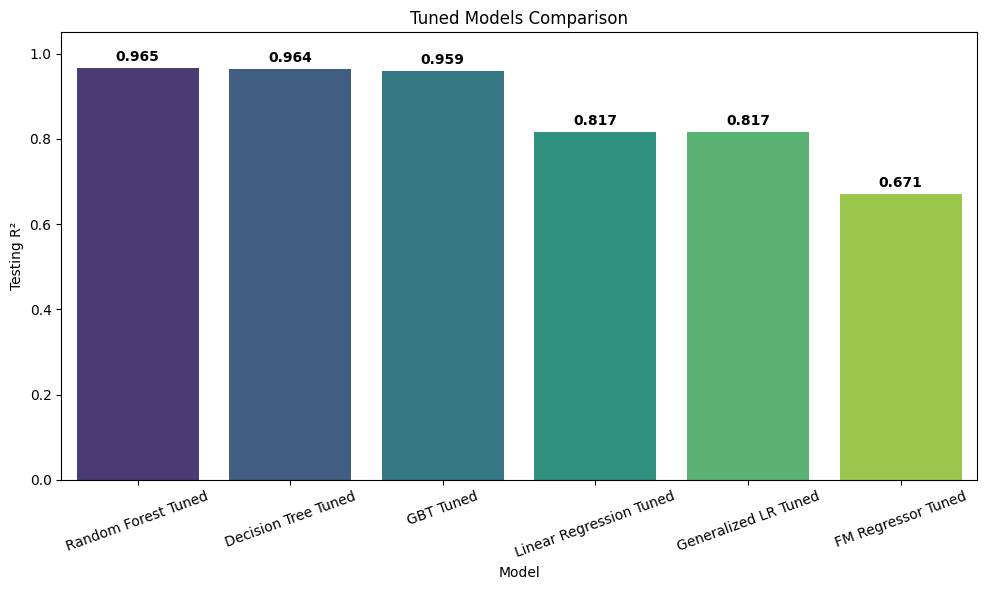

In [27]:
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x="Model", y="Test R2", data=tuned_results_df, palette="viridis")

for i, r2 in enumerate(tuned_results_df["Test R2"]):
    barplot.text(i, r2 + 0.01, f"{r2:.3f}", ha="center", va="bottom", fontweight="bold")

plt.ylim(0, 1.05)
plt.ylabel("Testing R²")
plt.xlabel("Model")
plt.title("Tuned Models Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [28]:
baseline_best_r2 = results_df["R2"].max()
baseline_best_model = results_df.loc[results_df["R2"].idxmax(), "Model"]

comparison_df = pd.DataFrame({
    "Version": ["Best Baseline", "Best Tuned"],
    "Model": [baseline_best_model, best_model_name],
    "R2": [baseline_best_r2, best_result["test_r2"]]
})

comparison_df

,Version,Model,R2
0,Best Baseline,GBT,0.947452
1,Best Tuned,Random Forest Tuned,0.965149


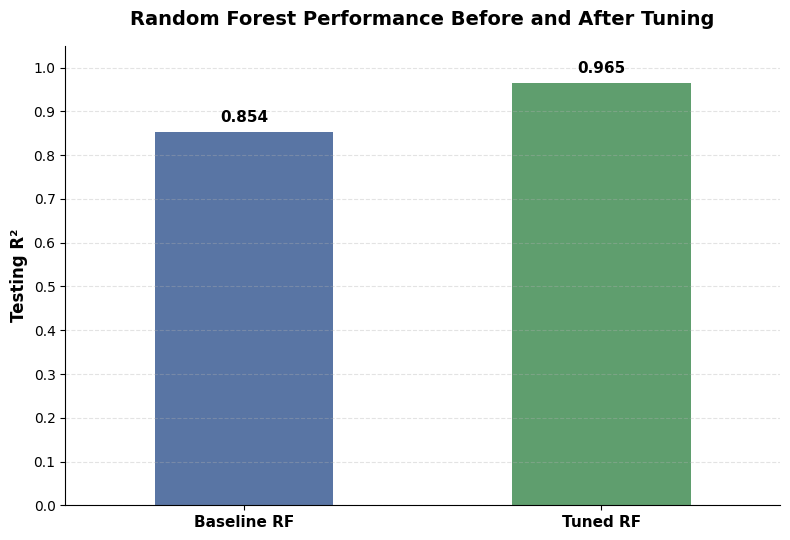

In [49]:
comparison_df = pd.DataFrame({
    "Version": ["Baseline RF", "Tuned RF"],
    "R2": [rf_r2, test_r2_rf_tuned]
})

plt.figure(figsize=(8, 5.5))

barplot = sns.barplot(
    x="Version",
    y="R2",
    data=comparison_df,
    palette=["#4C72B0", "#55A868"],
    width=0.5
)

for i, r2 in enumerate(comparison_df["R2"]):
    barplot.text(
        i,
        r2 + 0.015,
        f"{r2:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11
    )

plt.ylim(0, 1.05)
plt.ylabel("Testing R²", fontsize=12, fontweight="bold")
plt.xlabel("")
plt.title("Random Forest Performance Before and After Tuning", fontsize=14, fontweight="bold", pad=15)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=10)
plt.xticks(fontsize=11, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.35)

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

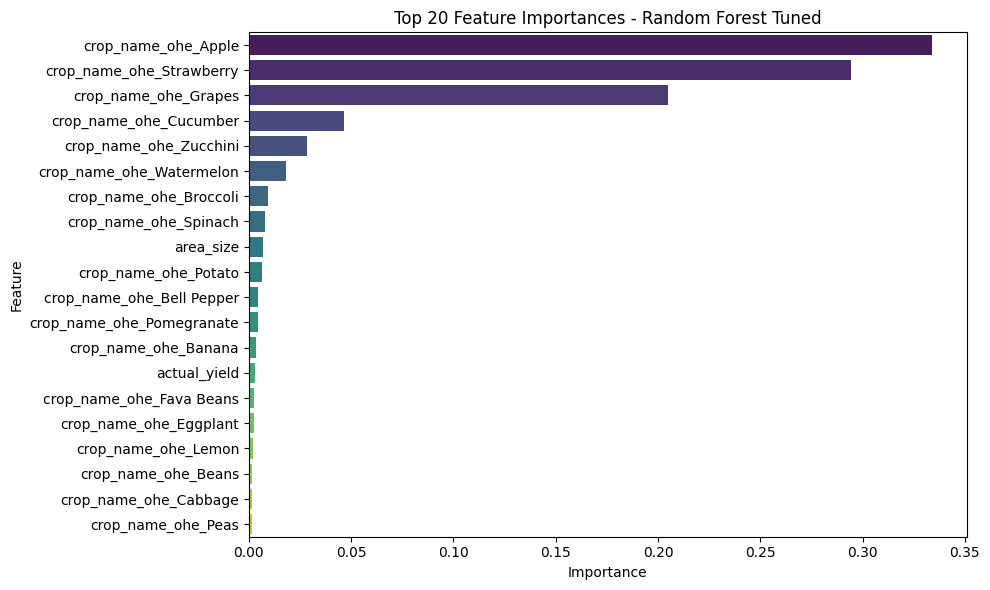

In [30]:
if best_model_name in ["Random Forest Tuned", "GBT Tuned"]:
    best_stage = best_cv_model.bestModel.stages[-1]
    best_transformed = best_cv_model.bestModel.transform(train_df)

    feature_metadata = best_transformed.schema["features"].metadata["ml_attr"]["attrs"]

    feature_names = []
    for attr_type in feature_metadata:
        feature_names.extend([attr["name"] for attr in feature_metadata[attr_type]])

    importance = best_stage.featureImportances.toArray()

    df_best_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    }).sort_values(by="importance", ascending=False)

    top_best_features = df_best_imp.head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_best_features, x="importance", y="feature", palette="viridis")
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    top_best_features

In [40]:
train_pred_rf_tuned = best_cv_model.bestModel.transform(train_df)
test_pred_rf_tuned = best_cv_model.bestModel.transform(test_df)

train_r2_rf_tuned = evaluator_r2.evaluate(train_pred_rf_tuned)
test_r2_rf_tuned = evaluator_r2.evaluate(test_pred_rf_tuned)

train_rmse_rf_tuned = evaluator_rmse.evaluate(train_pred_rf_tuned)
test_rmse_rf_tuned = evaluator_rmse.evaluate(test_pred_rf_tuned)

train_mae_rf_tuned = evaluator_mae.evaluate(train_pred_rf_tuned)
test_mae_rf_tuned = evaluator_mae.evaluate(test_pred_rf_tuned)

print("=== Tuned Random Forest Metrics ===")
print(f"Training R2:   {train_r2_rf_tuned:.4f}")
print(f"Testing R2:    {test_r2_rf_tuned:.4f}")
print(f"Training RMSE: {train_rmse_rf_tuned:.2f}")
print(f"Testing RMSE:  {test_rmse_rf_tuned:.2f}")
print(f"Training MAE:  {train_mae_rf_tuned:.2f}")
print(f"Testing MAE:   {test_mae_rf_tuned:.2f}")

diff_r2_rf_tuned = train_r2_rf_tuned - test_r2_rf_tuned

if diff_r2_rf_tuned > 0.05:
    verdict_rf_tuned = "⚠️ Overfitting"
elif test_r2_rf_tuned < 0.7:
    verdict_rf_tuned = "⚠️ Underfitting"
else:
    verdict_rf_tuned = "✅ Well-balanced"

print("\nModel verdict:", verdict_rf_tuned)

=== Tuned Random Forest Metrics ===
Training R2:   0.9826
Testing R2:    0.9651
Training RMSE: 60.41
Testing RMSE:  87.47
Training MAE:  38.97
Testing MAE:   45.79

Model verdict: ✅ Well-balanced


In [45]:
save_path = "rf_profit_model"

# remove old saved folder
if os.path.exists(save_path):
    shutil.rmtree(save_path)

# save Spark model
best_cv_model.bestModel.write().overwrite().save(save_path)

print("Model saved to:", save_path)
print("Model folder exists?", os.path.exists(save_path))

# zip folder
zip_file = shutil.make_archive(save_path, "zip", save_path)

print("Zip file created:", zip_file)
print("Zip file exists?", os.path.exists(zip_file))

Model saved to: rf_profit_model
Model folder exists? True
Zip file created: /content/rf_profit_model.zip
Zip file exists? True


In [46]:
files.download(zip_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>